<center></a>
<center><font size=10>    GenAI-Driven Stock Market Prediction</center></font>

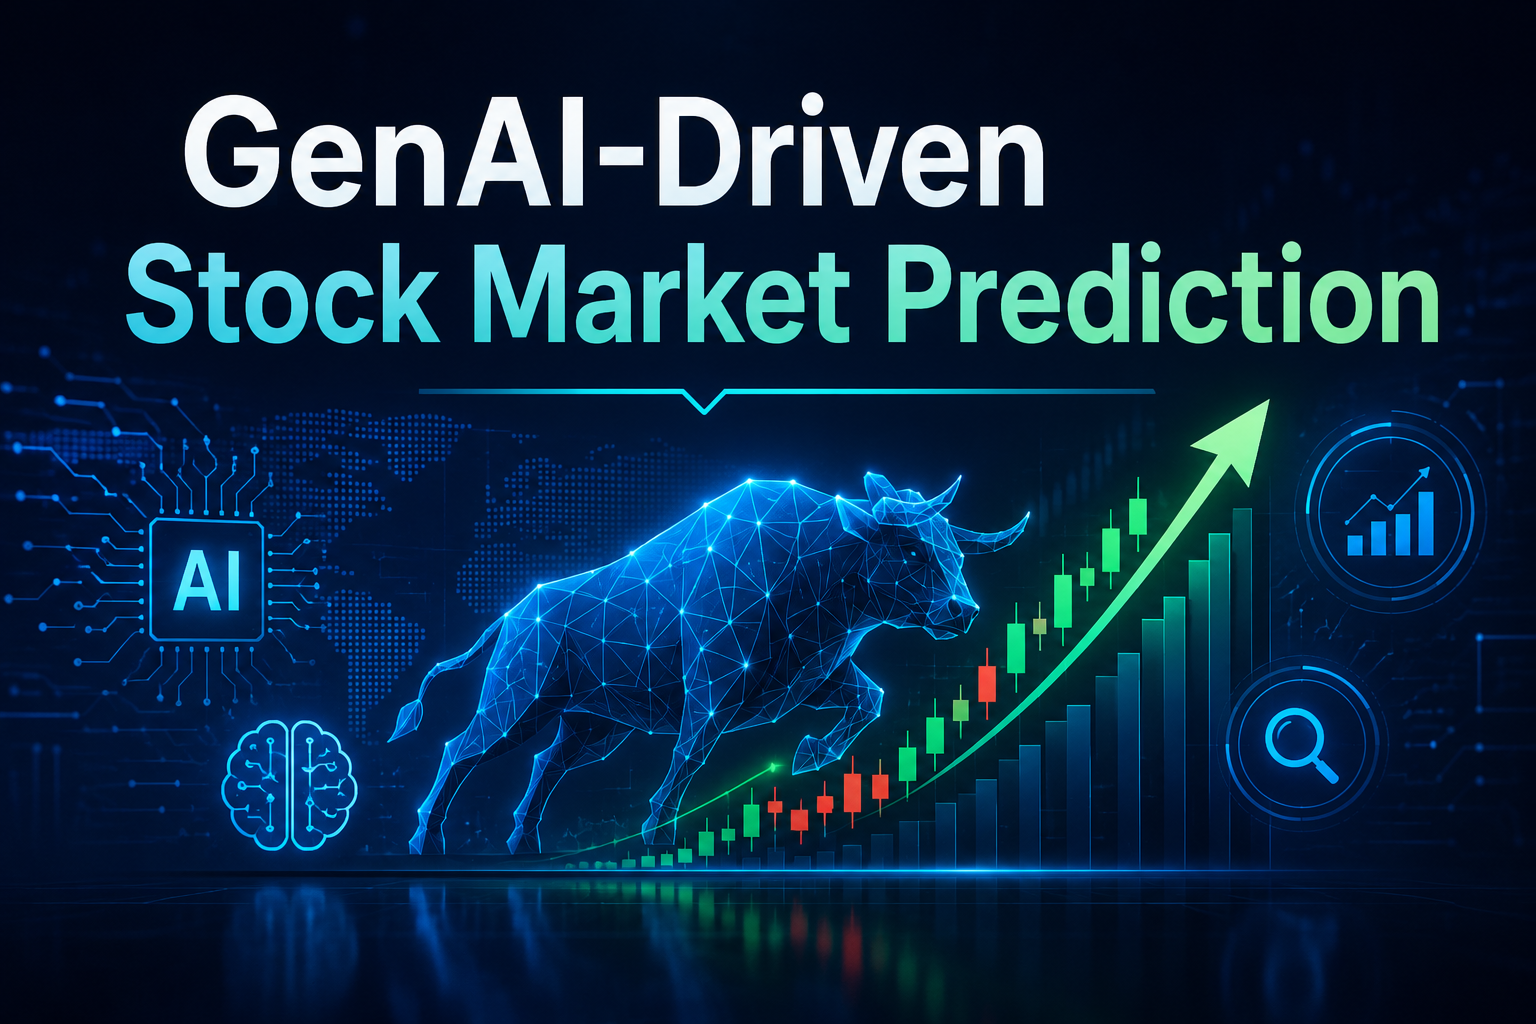

## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [2]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

!pip install -U transformers


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstal

In [1]:
!pip install gensim

In [2]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [3]:
import gensim
print(gensim.__version__)

4.4.0


## **Loading the dataset**

In [4]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# loading data into a pandas dataframe
News = pd.read_csv('/content/drive/MyDrive/Dataset/GenAIDataset/stock_news.csv')


In [6]:
# creating a copy of the data
data = News.copy()

## **Data Overview**

###**Checking the first 5 rows**

In [7]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


###**Checking the last 5 rows**

In [8]:
data.tail()

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


###**Checking the shape of the data**

In [9]:
data.shape

(349, 8)

###**Checking for missing values**

In [10]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


### **Checking for duplicate values**

In [11]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

In [12]:
# Check for duplicate rows
duplicate_rows = data[data.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")


Number of duplicate rows: 0


## **Exploratory Data Analysis**

In [13]:
# To display the structure of data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [14]:
#converting object column 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])

In [15]:
# To ensure the data type of Date
data['Date'].dtype

dtype('<M8[ns]')

In [16]:
# summary statistics for each numeric column
data.describe()

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

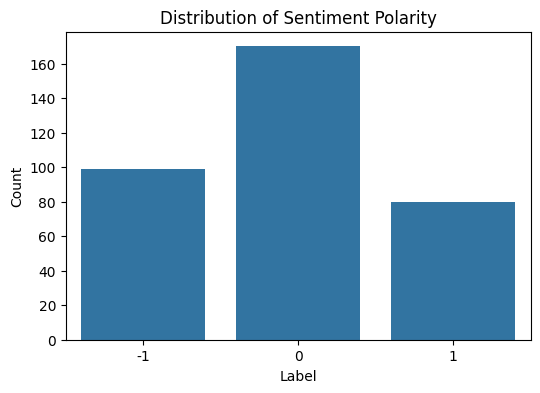

In [17]:
# Distribution of sentiment polarity
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='Label')
plt.title("Distribution of Sentiment Polarity")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

**Observations:**
- The dataset contains three sentiment classes — negative (-1), neutral (0), and positive (1) — and the counts are not perfectly balanced across the three classes.
- This class imbalance is worth keeping in mind when interpreting classification performance later, since accuracy alone can look better than it really is on imbalanced classes.

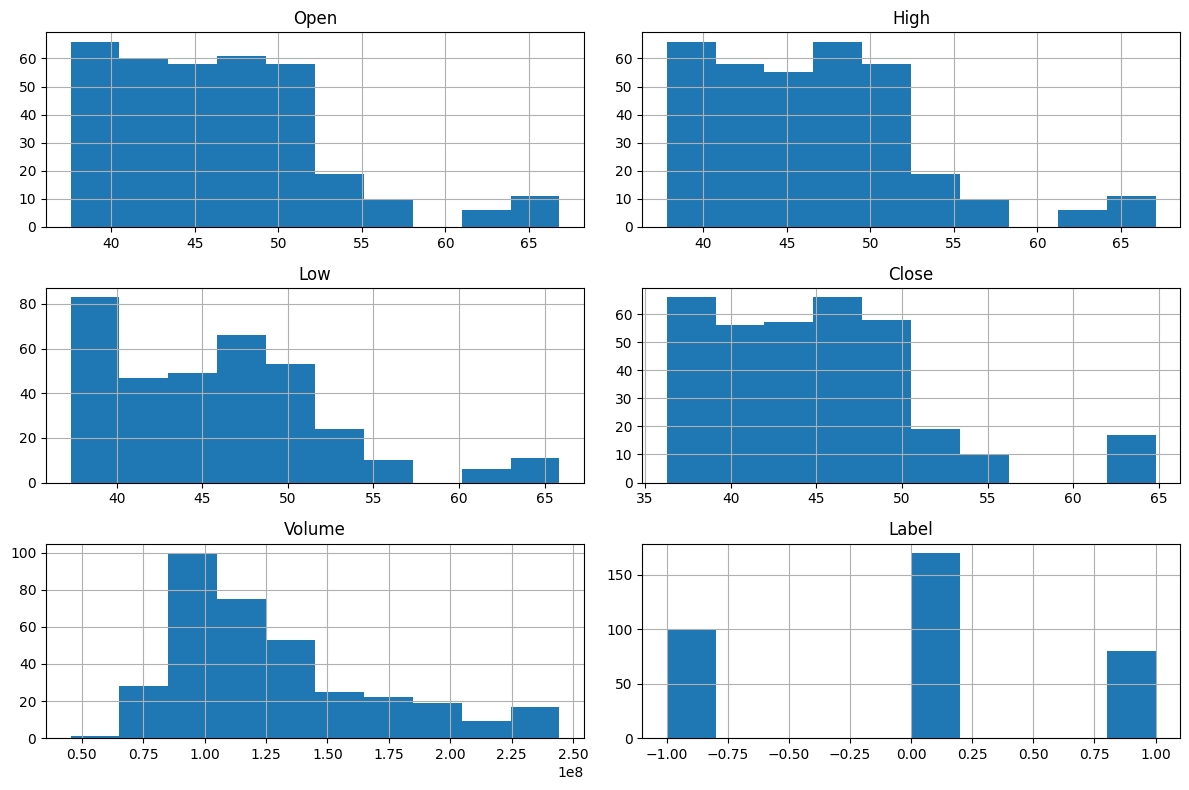

In [18]:
# Plot Distribution of all Numeric variables
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
data[numeric_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

**Observations:**
- Open, High, Low, and Close all show similar distributions, clustered mostly in the $40-$55 range, consistent with the ~4-month (January-April 2019) window covered by this dataset.
- Volume is heavily right-skewed — most trading days have a moderate volume, while a smaller number of days show unusually high trading activity.
- The Label histogram reflects the same three-class sentiment split seen in the earlier count plot.

### **Distribution of the length of news content**

In [19]:
# Compute length of news content (in words)
data['News_Length'] = data['News'].str.split().str.len()

# Summary statistics of news length
data['News_Length'].describe()



,News_Length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


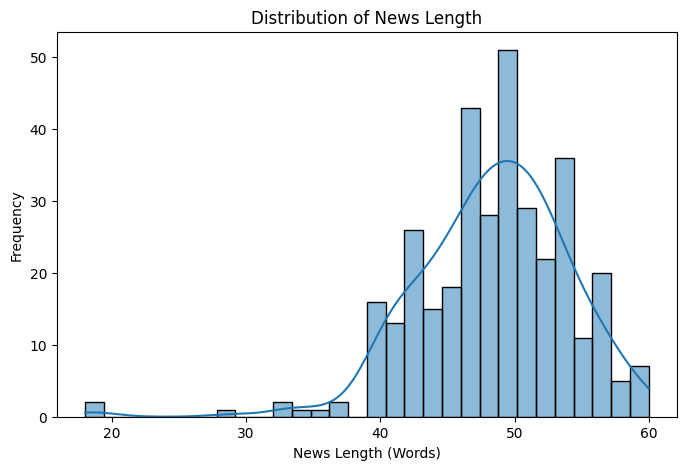

In [20]:
# Plot distribution
plt.figure(figsize=(8,5))
sns.histplot(data['News_Length'], bins=30, kde=True)
plt.title("Distribution of News Length")
plt.xlabel("News Length (Words)")
plt.ylabel("Frequency")
plt.show()

**Observations:**
- News article lengths are right-skewed — most articles are relatively short, with a smaller number of longer articles extending the tail of the distribution.
- This variation in article length is useful context for the embedding step later, since both Word2Vec and Sentence Transformer embeddings need to handle documents of very different lengths.

### **Monthwise Analysis**

In [21]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


<Figure size 1200x600 with 0 Axes>

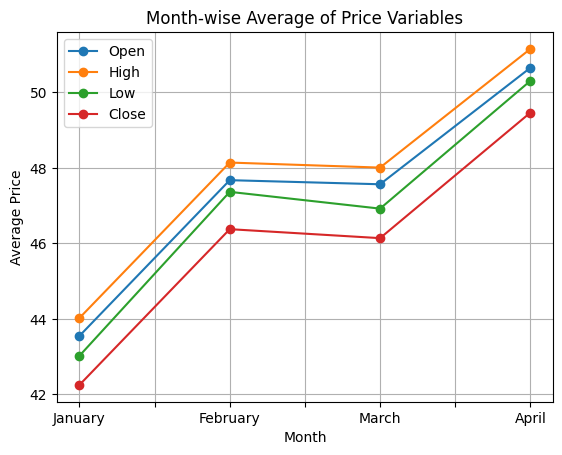

In [22]:
# plot the monthwise averages of all price variables for better visualization

# Extract month from Date
data['Month'] = data['Date'].dt.month_name()

# Calculate monthly average of price columns
monthly_avg = data.groupby('Month')[['Open', 'High', 'Low', 'Close']].mean()

# Arrange months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_avg = monthly_avg.reindex(month_order)

# Plot
plt.figure(figsize=(12,6))
monthly_avg.plot(marker='o')
plt.title('Month-wise Average of Price Variables')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()


* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

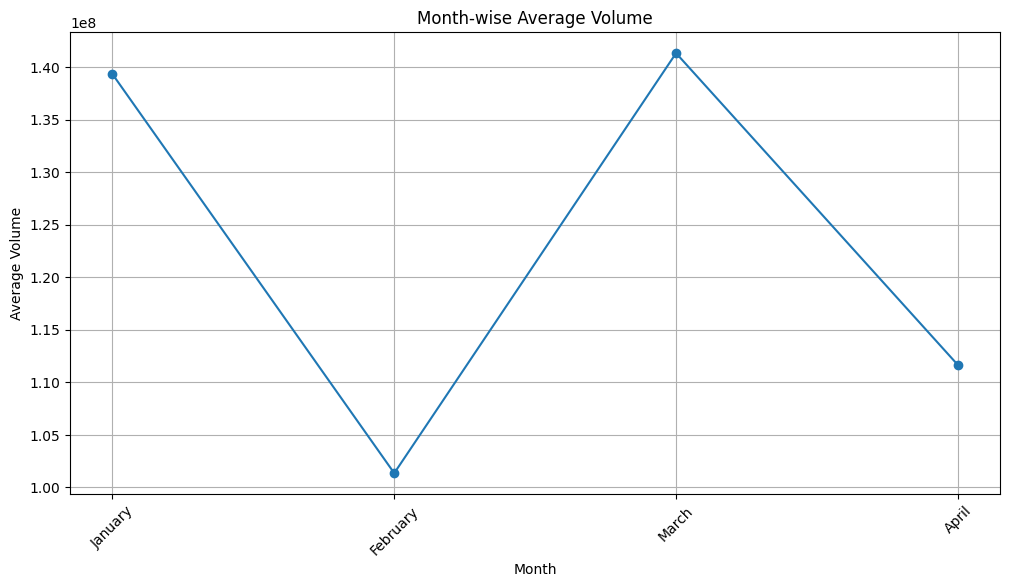

In [23]:
#plot the trend of monthwise averages in Volume

# Calculate month-wise average Volume
monthly_volume = data.groupby(data['Date'].dt.month_name())['Volume'].mean()

# Arrange months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_volume = monthly_volume.reindex(month_order)

# Plot the trend
plt.figure(figsize=(12,6))
plt.plot(monthly_volume.index, monthly_volume.values, marker='o')
plt.title('Month-wise Average Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


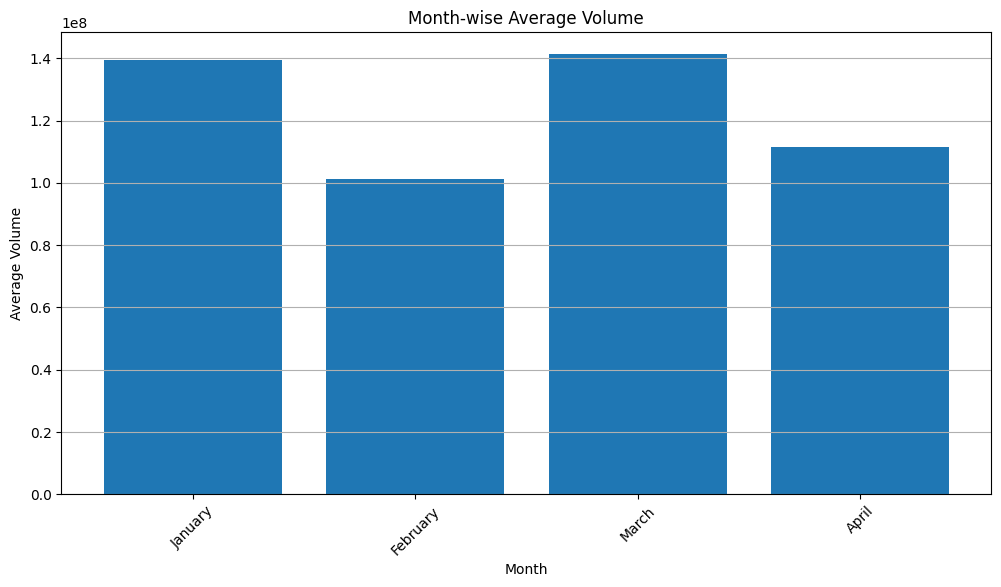

In [24]:
# Bar plot of the monthwise averages in Volume

# Calculate month-wise average Volume
monthly_volume = data.groupby(data['Date'].dt.month_name())['Volume'].mean()

# Arrange months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_volume = monthly_volume.reindex(month_order)

# Bar plot
plt.figure(figsize=(12,6))
plt.bar(monthly_volume.index, monthly_volume.values)
plt.title('Month-wise Average Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

**Observations:**
- Average trading volume fluctuates across the four months (January-April 2019) covered by the dataset, rather than following the steady upward trend seen in the price variables.
- This suggests trading volume is driven more by day-to-day news and events than by the same gradual growth pattern seen in prices.

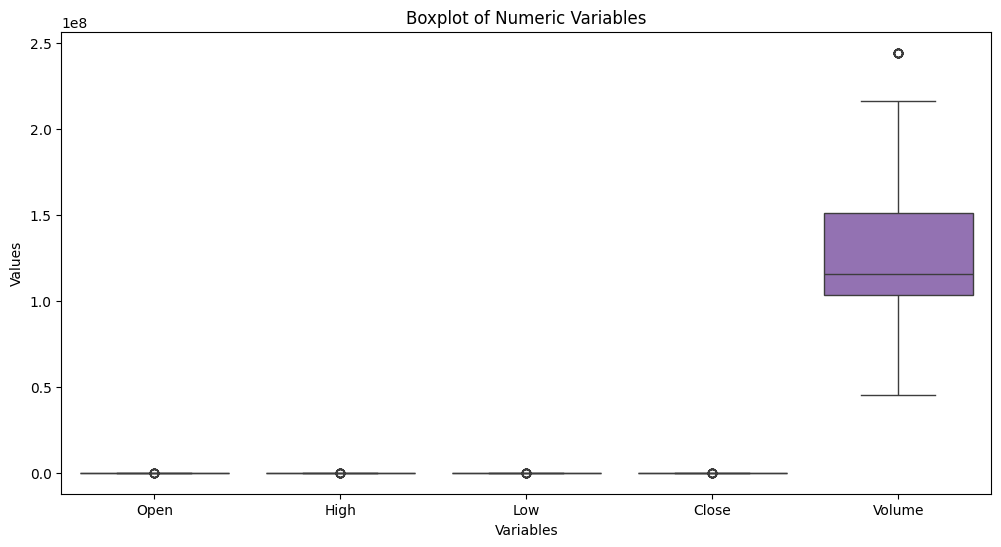

In [25]:
# Boxplot to identify outliers
plt.figure(figsize=(12,6))

sns.boxplot(data=data[['Open', 'High', 'Low', 'Close', 'Volume']])

plt.title('Boxplot of Numeric Variables')
plt.xlabel('Variables')
plt.ylabel('Values')
plt.show()

**Observations:**
- Since Volume is on a much larger scale (hundreds of millions) than the price variables (Open, High, Low, Close, roughly $37-$55), plotting them together on the same axis makes the price boxplots appear flat.
- Volume needs to be visualized on its own (as done in the next plot) to properly assess its spread and outliers.

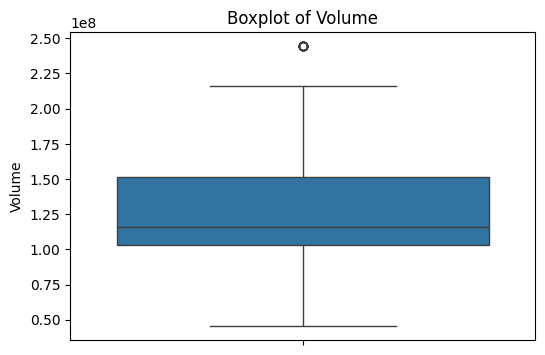

In [26]:
# Boxplot to identify single column outliers
plt.figure(figsize=(6,4))

sns.boxplot(y=data['Volume'])

plt.title('Boxplot of Volume')
plt.ylabel('Volume')
plt.show()

**Observations:**
- The Volume boxplot shows several points above the upper whisker, indicating a number of days with unusually high trading volume compared to the typical range.
- These outlier days are likely linked to major news events, earnings announcements, or other market-moving developments.

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

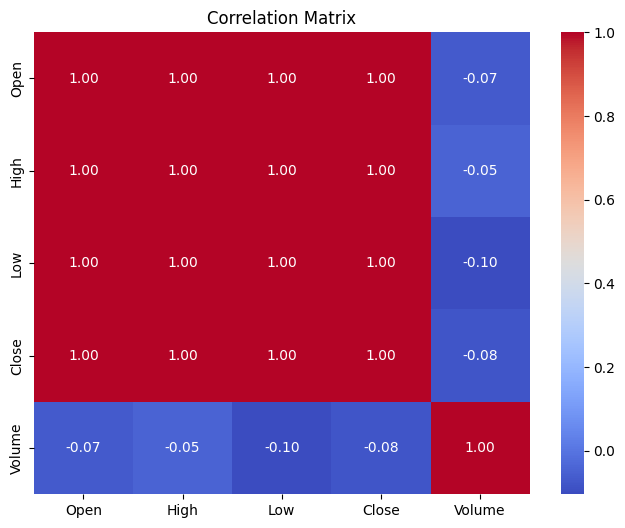

In [27]:
# Correlation matrix to check if variables move together or have correlations
corr_matrix = data[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

**Observations:**
- Open, High, Low, and Close are very strongly correlated with one another (correlation close to 1), which is expected since they all move together within the same trading day.
- Volume shows a much weaker relationship with the price variables, suggesting trading volume is driven by different factors than the day's price level.

### **Sentiment Polarity vs Price**

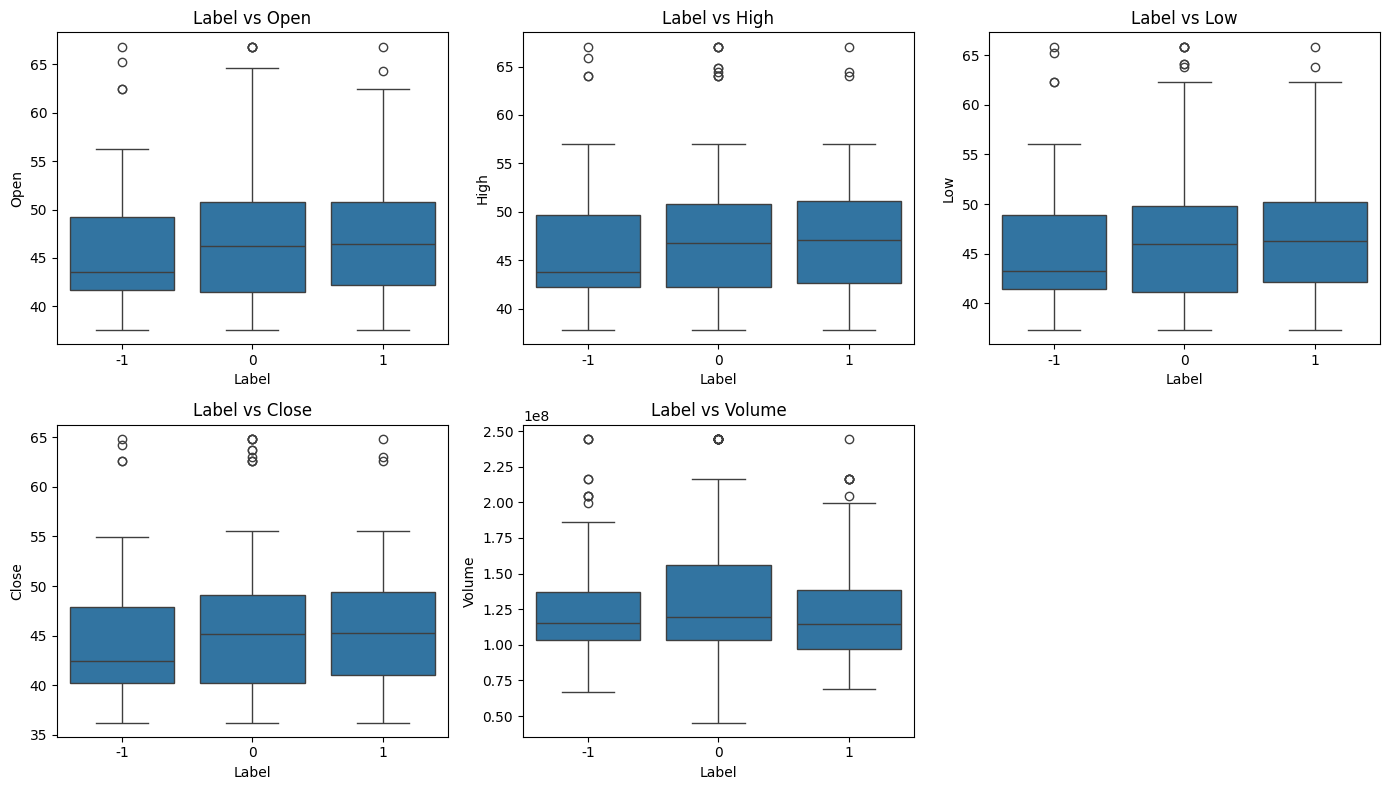

In [28]:
#Sentiment Polarity with all numeric variables
plt.figure(figsize=(14,8))

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Label', y=col, data=data)
    plt.title(f'Label vs {col}')

plt.tight_layout()
plt.show()

**Observations:**
- Price distributions (Open, High, Low, Close) look fairly similar across the three sentiment labels, with overlapping ranges — suggesting the price level on a given day is not, by itself, a strong indicator of that day's news sentiment.
- This reinforces the need for text-based features (via Word2Vec/Sentence Transformer embeddings) rather than price alone to classify news sentiment.

### **Time Series Analysis (Date vs Price)**

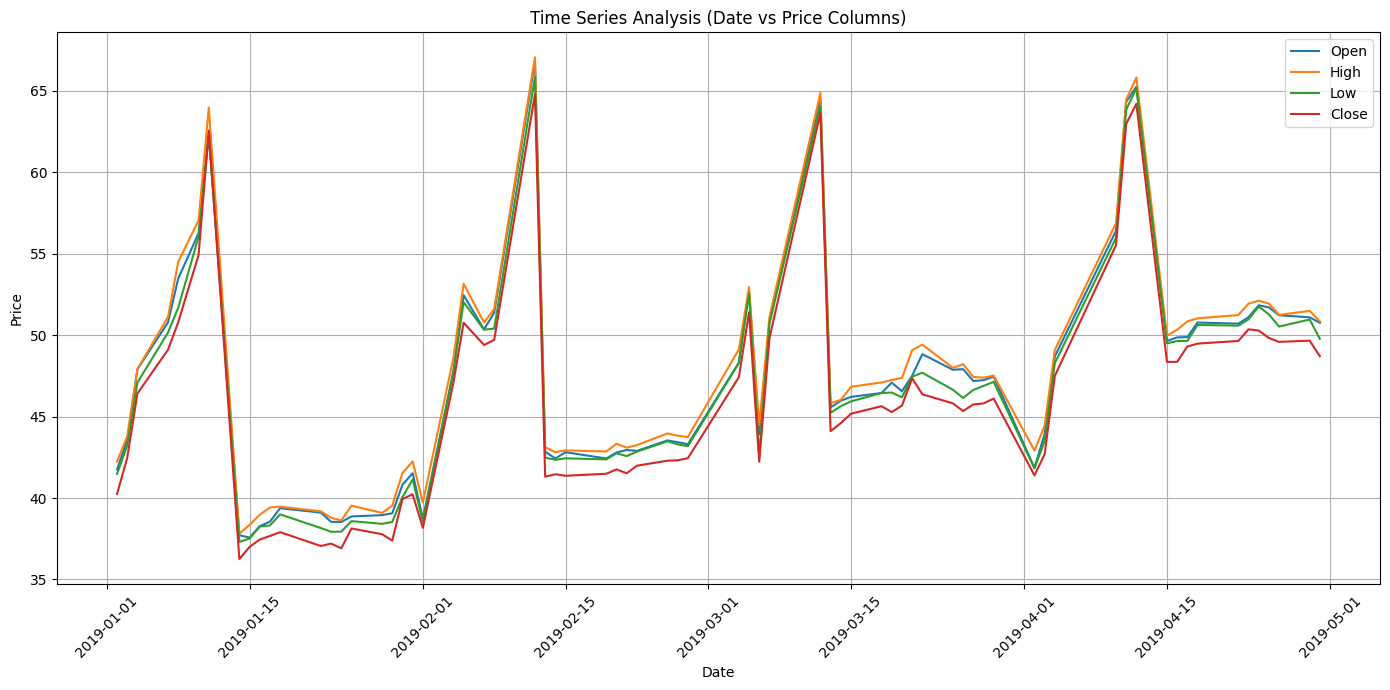

In [29]:
#Time Series Analysis (Date vs Price columns)
plt.figure(figsize=(14,7))

plt.plot(data['Date'], data['Open'], label='Open')
plt.plot(data['Date'], data['High'], label='High')
plt.plot(data['Date'], data['Low'], label='Low')
plt.plot(data['Date'], data['Close'], label='Close')

plt.title('Time Series Analysis (Date vs Price Columns)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observations:**
- Open, High, Low, and Close track each other closely throughout the January-April 2019 period, confirming the strong correlation seen in the heatmap.
- The overall price trend is upward over the period, with some short-term dips and fluctuations along the way.

### **Distribution of News Length Across Sentiment Categories**

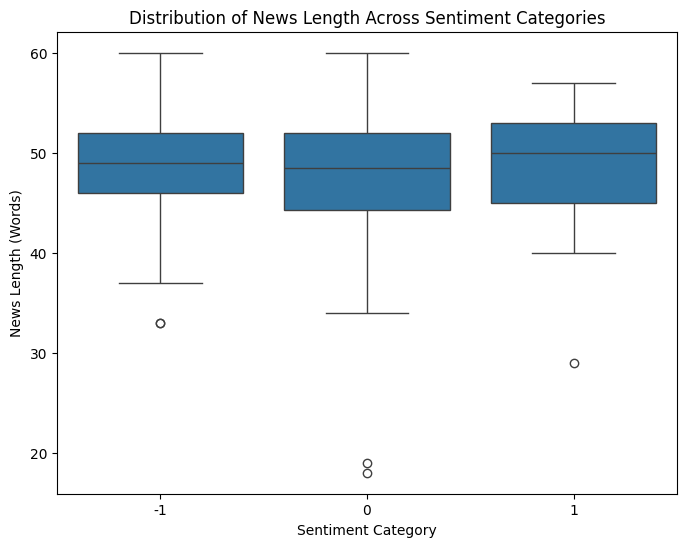

In [30]:
# Calculate news length (number of words)
data['News_Length'] = data['News'].apply(lambda x: len(str(x).split()))

# Distribution of News Length Across Sentiment Categories
plt.figure(figsize=(8,6))
sns.boxplot(x='Label', y='News_Length', data=data)

plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Sentiment Category')
plt.ylabel('News Length (Words)')
plt.show()

**Observations:**
- News article length is broadly similar across the three sentiment categories, with overlapping distributions.
- This suggests sentiment is conveyed more through word choice and content than through article length alone.

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [31]:
# Storing target variable
y = data['Label']


## **Word Embeddings**


#### **Word2Vec**

In [32]:
from gensim.models import Word2Vec

sentences = [str(news).split() for news in data['News']]

model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

In [33]:
# Creating a list of all words in our data
words = []

for news_item in data['News']:
    for word in str(news_item).split():
        words.append(word)

print(words[:20])

['The', 'tech', 'sector', 'experienced', 'a', 'significant', 'decline', 'in', 'the', 'aftermarket', 'following', "Apple's", 'Q1', 'revenue', 'warning.', 'Notable', 'suppliers,', 'including', 'Skyworks,', 'Broadcom,']


In [34]:

# Retrieving word vectors for all the words present in the model's vocabulary
vec_size = model.vector_size

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = {}

for word in words:
    word_vector_dict[word] = model.wv[word]

In [35]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [36]:
# creating a dataframe of the vectorized documents
word2vec_embeddings = pd.DataFrame(
    [average_vectorizer_Word2Vec(doc) for doc in data['News']]
)

word2vec_embeddings.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.047252,0.061694,0.010260,-0.013712,0.028573,-0.094397,0.043122,0.174872,-0.086301,-0.061502,...,0.094814,0.015130,0.028396,0.004383,0.139400,0.056005,0.032001,-0.061438,0.020267,0.015730
1,-0.044660,0.058806,0.009425,-0.015072,0.025794,-0.090646,0.040769,0.167071,-0.083644,-0.057941,...,0.091587,0.014075,0.026334,0.002778,0.133836,0.053058,0.030955,-0.057680,0.020776,0.014176
2,-0.040617,0.053497,0.007981,-0.012701,0.024702,-0.082823,0.035303,0.153420,-0.077808,-0.052201,...,0.084385,0.012381,0.025688,0.004661,0.122168,0.047695,0.027834,-0.051360,0.018450,0.012824
3,-0.049258,0.064798,0.010867,-0.014387,0.028995,-0.096888,0.042944,0.176629,-0.090073,-0.062054,...,0.096446,0.014723,0.028031,0.002684,0.141481,0.056303,0.033288,-0.059588,0.021228,0.015380
4,-0.045552,0.060178,0.007431,-0.013856,0.028221,-0.090738,0.040379,0.168310,-0.083942,-0.057033,...,0.092078,0.015138,0.028527,0.004318,0.136117,0.051290,0.032109,-0.057561,0.020750,0.016327


## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [37]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

##### Encoding the dataset

In [38]:
embedding_matrix = model.encode(
    data['News'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [39]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(349, 768)

## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [40]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [41]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

In [42]:
# Storing independent variable
X = word2vec_embeddings



In [43]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [44]:
# Building the model
rf_model = RandomForestClassifier(random_state=42)
# Fitting on train data
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [45]:
# Predicting on train data
y_pred_train = rf_model.predict(X_train)

# Predicting on test data
y_pred_test = rf_model.predict(X_test)

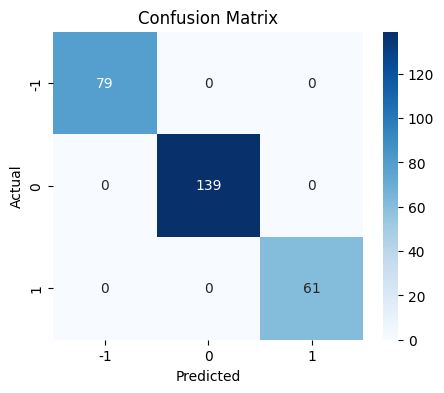

In [46]:
plot_confusion_matrix(y_train, y_pred_train)

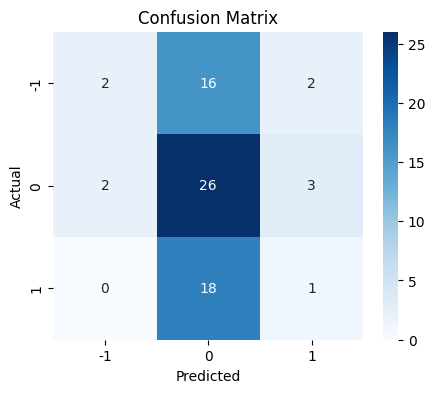

In [47]:
plot_confusion_matrix(y_test, y_pred_test)

In [48]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.414286 0.414286       0.38 0.322395


###**Sentence Transformer-Random Forest Model**

In [49]:
# Storing independent variable
X = embedding_matrix


In [50]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:

# Building the model
rf_model = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [52]:
# Predicting on train data
y_train_pred = rf_model.predict(X_train)

# Predicting on test data
y_test_pred = rf_model.predict(X_test)

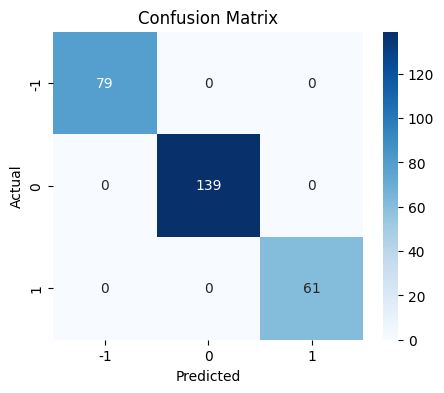

In [53]:
plot_confusion_matrix(y_train, y_train_pred)

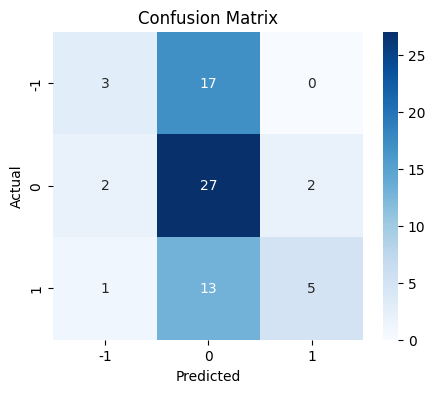

In [54]:
plot_confusion_matrix(y_test, y_test_pred)

In [55]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_train_pred)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_test_pred)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

In [56]:
# Storing independent variable
X = word2vec_embeddings

In [57]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [58]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [59]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')   # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.4409 - loss: 1.0830 - val_accuracy: 0.4429 - val_loss: 1.0786
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0513 - val_accuracy: 0.4429 - val_loss: 1.0771
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0387 - val_accuracy: 0.4429 - val_loss: 1.0876
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0370 - val_accuracy: 0.4429 - val_loss: 1.0928
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0386 - val_accuracy: 0.4429 - val_loss: 1.0883
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0372 - val_accuracy: 0.4429 - val_loss: 1.0895
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0368 - val_accuracy: 0.4429 - val_loss: 1.0860
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0367 - val_accuracy: 0.4429 - val_loss: 1.0851


In [61]:
# Predict class probabilities on training data
y_test_prob = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_prob, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [62]:
# Predict class probabilities on test data
y_train_prob = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_prob, axis=1)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


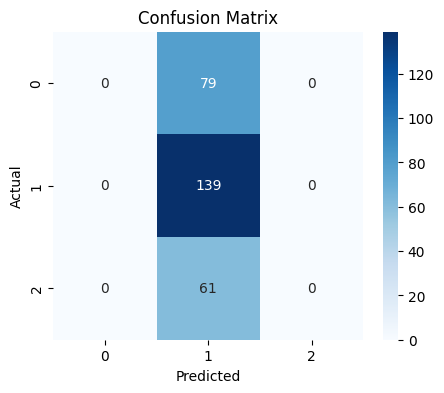

In [63]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

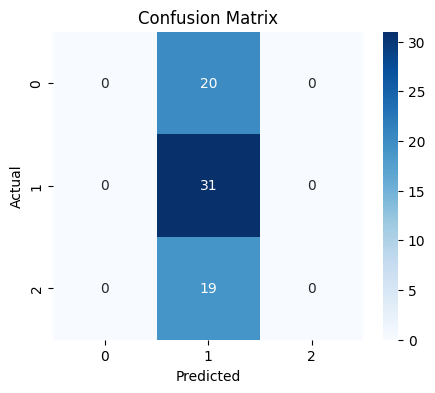

In [64]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [65]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [66]:
X = embedding_matrix

In [67]:

# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [69]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')   # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4552 - loss: 1.0677 - val_accuracy: 0.4429 - val_loss: 1.0639
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4982 - loss: 1.0140 - val_accuracy: 0.4429 - val_loss: 1.0642
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 0.9746 - val_accuracy: 0.4429 - val_loss: 1.0235
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5233 - loss: 0.9307 - val_accuracy: 0.4857 - val_loss: 0.9864
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5448 - loss: 0.8743 - val_accuracy: 0.4714 - val_loss: 0.9577
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6416 - loss: 0.8011 - val_accuracy: 0.5571 - val_loss: 0.9201
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6738 - loss: 0.7394 - val_accuracy: 0.5571 - val_loss: 0.9092
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7240 - loss: 0.6716 - val_accuracy: 0.5714 - val_loss: 0.9205


In [71]:
# Predict class probabilities on training data
y_train_prob = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_prob, axis=1)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [72]:
# Predict class probabilities on test data
y_test_prob = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_prob, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


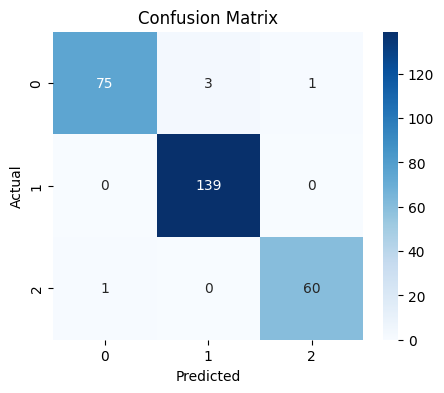

In [73]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

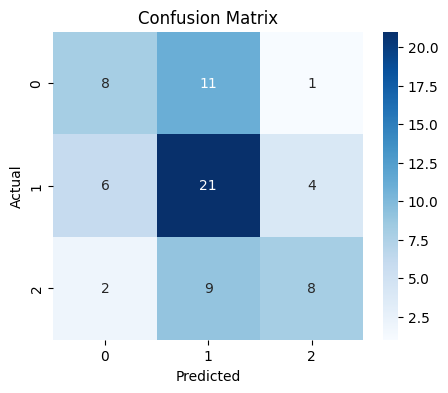

In [74]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [75]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.982079 0.982079   0.982165 0.981963
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.528571 0.528571   0.536719 0.521032


#### **Generating Embeddings with Sentence Transformers using the all-MiniLM-L6-v2 embeddings**

In [76]:
model_minilm = SentenceTransformer('all-MiniLM-L6-v2')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

##### Encoding the dataset

In [77]:
embedding_matrix_minilm = model_minilm.encode(
    data['News'].tolist(),
    show_progress_bar=True
)


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [78]:
# printing the shape of the embedding matrix
embedding_matrix_minilm.shape


(349, 384)

### **MiniLM-Random Forest Model**

In [79]:
# Storing independent variable
X = embedding_matrix_minilm


In [80]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [81]:
# Building the model
rf_model = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [82]:
# Predicting on train data
y_train_pred = rf_model.predict(X_train)

# Predicting on test data
y_test_pred = rf_model.predict(X_test)


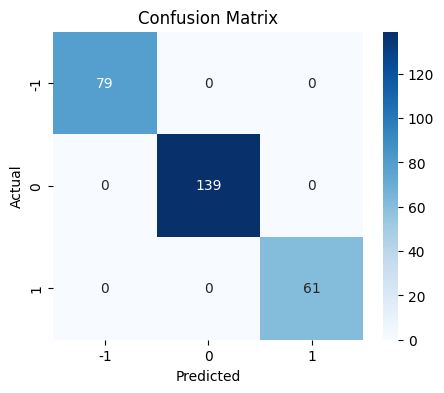

In [83]:
plot_confusion_matrix(y_train, y_train_pred)


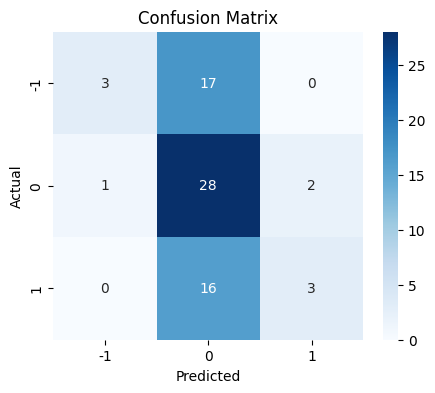

In [84]:
plot_confusion_matrix(y_test, y_test_pred)


In [85]:
train_transformer_MiniLM_RF = model_performance_classification_sklearn(y_train,y_train_pred)
print("Training set performance metrics:")
print(train_transformer_MiniLM_RF.to_string(index=False))
test_transformer_MiniLM_RF = model_performance_classification_sklearn(y_test,y_test_pred)
print("Test set performance metrics:")
print(test_transformer_MiniLM_RF.to_string(index=False))


Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.580422 0.408851


### **MiniLM-Neural Network Model**

In [86]:
X = embedding_matrix_minilm


In [87]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [88]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])


In [89]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')   # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,731 (225.51 KB)

 Trainable params: 57,731 (225.51 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.4588 - loss: 1.0775 - val_accuracy: 0.4429 - val_loss: 1.0624
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4982 - loss: 1.0156 - val_accuracy: 0.4429 - val_loss: 1.0513
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4982 - loss: 0.9747 - val_accuracy: 0.4429 - val_loss: 1.0462
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5090 - loss: 0.9234 - val_accuracy: 0.4857 - val_loss: 1.0182
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5627 - loss: 0.8662 - val_accuracy: 0.5286 - val_loss: 0.9923
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6201 - loss: 0.8015 - val_accuracy: 0.5429 - val_loss: 0.9670
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7168 - loss: 0.7300 - val_accuracy: 0.5714 - val_loss: 0.9383
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7527 - loss: 0.6583 - val_accuracy: 0.5714 - val_loss: 0.9485


In [91]:
# Predict class probabilities on training data
y_train_prob = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_prob, axis=1)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [92]:
# Predict class probabilities on test data
y_test_prob = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_prob, axis=1)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


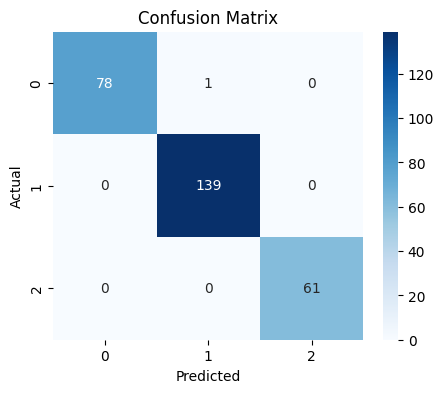

In [93]:
plot_confusion_matrix(y_train_mapped, y_train_preds)


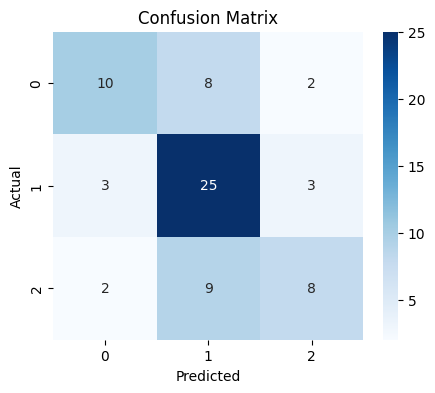

In [94]:
plot_confusion_matrix(y_test_mapped, y_test_preds)


In [95]:
train_transformer_MiniLM_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_MiniLM_NN.to_string(index=False))
test_transformer_MiniLM_NN = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_MiniLM_NN.to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.996416 0.996416   0.996441 0.996411
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.614286 0.614286   0.621115 0.602306


### **Model Performance Summary and Final Model Selection**

In [96]:

# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        train_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,1.0,0.498208,1.0,0.982079,1.0,0.996416
Recall,1.0,0.498208,1.0,0.982079,1.0,0.996416
Precision,1.0,0.248211,1.0,0.982165,1.0,0.996441
F1,1.0,0.331344,1.0,0.981963,1.0,0.996411


In [97]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        test_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,0.414286,0.442857,0.500000,0.528571,0.485714,0.614286
Recall,0.414286,0.442857,0.500000,0.528571,0.485714,0.614286
Precision,0.380000,0.196122,0.546509,0.536719,0.580422,0.621115
F1,0.322395,0.271853,0.442083,0.521032,0.408851,0.602306


In [98]:
print("Final Model Selection: Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)")
print(models_test_comp_df[["Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"]].to_string())

Final Model Selection: Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
           Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy                                                 0.614286
Recall                                                   0.614286
Precision                                                0.621115
F1                                                       0.602306


## **News Summarization**

### **Weekly News Aggregation**

In [99]:
# Create a Week column to group news at a weekly level
data['Week'] = data['Date'].dt.to_period('W').astype(str)

# Combine all news articles within the same week into one text block
weekly_news = (
    data.groupby('Week')['News']
        .apply(lambda x: ' '.join(x.astype(str)))
        .reset_index()
)

weekly_news.head()


Week  \
0  2018-12-31/2019-01-06   
1  2019-01-07/2019-01-13   
2  2019-01-14/2019-01-20   
3  2019-01-21/2019-01-27   
4  2019-01-28/2019-02-03   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

### **Generating Summaries using T5**

In [101]:
tokenizer = T5Tokenizer.from_pretrained('t5-small')
model_t5 = T5ForConditionalGeneration.from_pretrained('t5-small')

def summarize_text(text, max_len=150, min_len=40):
    text = "summarize: " + text[:3000]
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    summary_ids = model_t5.generate(
        inputs["input_ids"],
        max_length=max_len,
        min_length=min_len,
        num_beams=4,
        early_stopping=True
    )
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

weekly_news['Weekly_Summary'] = weekly_news['News'].apply(summarize_text)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

In [105]:
weekly_news[['News', 'Weekly_Summary']].head()

News  \
0   The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.  Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10  Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon  This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple  Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets Apple CEO Tim Cook discussed the company's Q1 warning on CNBC, attributing US-China trade tensions as a factor. Despite not mentioning iPhone unit sales specifically, Cook indicated Apple may comment on them again. Services revenue is projected to exceed $10.8 billion in Q1. Cook also addressed the lack of  Roku Inc has announced plans to offer premium video channels on a subscription basis through its free streaming service, The Roku Channel. Partners include CBS Corp's Showtime, Lionsgate's Starz, and Viacom Inc's Noggin. This model follows Amazon's successful Channels business, which generated an estimated  Wall Street saw modest gains on Wednesday but were threatened by fears of a global economic slowdown following Apple's shocking revenue forecast cut, blaming weak demand in China. The tech giant's suppliers and S&P 500 futures also suffered losses. Reports of decelerating factory activity in China and the euro zone  Apple's fiscal first quarter revenue came in below analysts' estimates at around $84 billion, a significant drop from the forecasted range of $89-$93 billion. The tech giant attributed the shortfall to lower iPhone revenue and upgrades, as well as weakness in emerging markets. Several brokerages had already reduced their production estimates  Apple Inc. lowered its quarterly sales forecast for the fiscal first quarter, underperforming analysts' expectations due to slowing Chinese economy and trade tensions. The news sent Apple shares tumbling and affected Asia-listed suppliers like Hon Hai Precision Industry Co Ltd, Taiwan Semiconductor Manufacturing Company, and LG Innot  The Australian dollar experienced significant volatility on Thursday, plunging to multi-year lows against major currencies due to automated selling, liquidity issues, and a drought of trades. The largest intra-day falls in the Aussie's history occurred amid violent movements in AUD/JPY and AUD/  In early Asian trading on Thursday, the Japanese yen surged as the U.S. dollar and Australian dollar collapsed in thin markets due to massive stop loss sales triggered by Apple's earnings warning of sluggish iPhone sales in China and risk aversion. The yen reached its lowest levels against the U.S. dollar since March   The dollar fell from above 109 to 106.67 after Apple's revenue warning, while the 10-year Treasury yield also dropped to 2.61%. This followed money flowing into US government paper. Apple's shares and

In [106]:
def summarize_text(text, max_len=150, min_len=40):
    text = "summarize: " + text[:3000]
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    summary_ids = model_t5.generate(
        inputs["input_ids"],
        max_length=max_len,
        min_length=min_len,
        num_beams=4,
        early_stopping=True
    )
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Generating a summary for each week's combined news
weekly_news['Weekly_Summary'] = weekly_news['News'].apply(summarize_text)

In [107]:
# Viewing the weekly summaries
weekly_news[['Week', 'Weekly_Summary']].head(10)


,Week,Weekly_Summary
0,2018-12-31/2019-01-06,"notable suppliers, including skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter. apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales."
1,2019-01-07/2019-01-13,AMS aims to reduce its dependence on Apple and boost its battered shares. AMS provides optical sensors for apple's 3D facial recognition feature on iPhones. it forecasts flat sales for 2019 due to economic slowdown and cautious consumers.
2,2019-01-14/2019-01-20,"tech stocks suffered the most significant losses on monday. a halt in Europe's four-day stock market rally led to a halt in Europe's stock market rally. luxury retailers, including LVMH, Hermes, Kering, Moncler, and Pandora, dropped between 1% and 7%."
3,2019-01-21/2019-01-27,the governor of the bank says negative interest rates and foreign currency market intervention are necessary to prevent a strong franc from causing deflation in the country. the bank's bearish outlook on global growth and weak existing home sales data also IBM's stock price increased after hours due to better-than-expected earnings and revenue.
4,2019-01-28/2019-02-03,"Caterpillar Inc reported lower-than-expected fourth quarter earnings and full year 2019 outlook due to weak demand in China's construction business. the company's shares fell by 5%, pulling down U.S. stock futures. since 2011, apple has generated or supported over 2 million jobs across all 50 states in Apple is expected to report lower-than-projected fiscal first quarter earnings."
5,2019-02-04/2019-02-10,"the Dow Jones Industrial Average, S&P 500, and Nasdaq Composite rose on Monday. the company's shares surged to nine-week highs on Tuesday, boosted by a rebound in banks and gains in oil stocks."
6,2019-02-11/2019-02-17,the european commission orders Belgium to recover €790 million from these firms. revenue from its cloud security business rose 36% to $185 million. the security unit is expected to exceed $1 billion in annual revenue soon.
7,2019-02-18/2019-02-24,"the number of films with female leads has increased, as have Oscar WhatsApp. the issue arises when users select any interval other than immediate verification. WhatsApp said a fix Garmin reported stronger-than-expected earnings and revenue."
8,2019-02-25/2019-03-03,"the Dow Jones Industrial Average and other major indexes posted gains on Monday, with the Dow rising 60 points. some tariffs are expected to remain as an enforcement mechanism. the company forecasted a profit decline of 65-75% compared to the same period last year and narrowing gross profit margins."
9,2019-03-04/2019-03-10,"Spotify, the world's largest paid music streaming platform, reported 1 million unique users in India within a week of launch. the company offers a free version with ads and a premium ad-free variant for 119 Indian rupees per month. the company is considering revoking DarkMatter's authority to certify websites as safe due to reports linking the cybersecurity firm to a UAE-based intelligence agency's hacking program."


## **Conclusions and Recommendations**

#### **Conclusions**



In this project, Word2Vec and Sentence Transformer embeddings were used to convert text into meaningful numerical representations for sentiment analysis. Word2Vec captured semantic relationships between words based on this dataset alone, while Sentence Transformers (BAAI/bge-base-en-v1.5 and all-MiniLM-L6-v2) generated context-aware sentence embeddings, pretrained on large external corpora, that better represented the overall meaning of the text.

The generated embeddings were used to train two machine learning models: Random Forest and Neural Networks. Random Forest achieved perfect training performance (Accuracy/F1 = 1.0) with all embedding types, but this came at the cost of significant overfitting — test accuracy dropped to ~41-50%, showing the model memorized the training data rather than learning generalizable patterns. The Neural Network models, particularly with Sentence Transformer embeddings, showed a smaller train-test gap and achieved better generalization to unseen news articles. Among all six model-embedding combinations, the **Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)** model achieved the best overall test performance (Accuracy ~61.4%, F1 ~0.60), outperforming even the BAAI/bge-base-en-v1.5 (Neural Network) model (Accuracy ~52.9%, F1 ~0.52).

Across both model types, Sentence Transformer embeddings consistently outperformed Word2Vec embeddings on the test set, confirming that pretrained, context-aware embeddings add meaningful value over embeddings trained from scratch on a relatively small news dataset.

Overall, the project shows that combining modern text embedding methods with machine learning models can effectively classify sentiment from textual data, while also highlighting the importance of addressing overfitting and dataset size for more reliable real-world performance. The weekly news summarization component further complements this by giving analysts quick, readable context alongside the sentiment signal, supporting more informed investment decisions.

**Models used:**

**Word2Vec**

**Sentence Transformer embeddings**

**Neural Networks**

**Random Forest**

#### **Recommendations**

## Recommendations

* Fine-tune the best-performing Sentence Transformer (all-MiniLM-L6-v2) embeddings on domain-specific financial/stock-news text to improve sentiment classification performance further.
* Address overfitting in the Random Forest models (which achieved a perfect 1.0 on training data but dropped to ~41-50% on test data) using techniques such as limiting `max_depth`, tuning `min_samples_leaf`, and applying cross-validation instead of a single train-test split.
* Increase the size and diversity of the dataset to improve the model's ability to generalize to unseen data.
* Perform hyperparameter tuning for both Random Forest and Neural Network models to achieve better accuracy and robustness (e.g., Dropout and L2 regularization for the Neural Network to reduce the train-test performance gap).
* Experiment with additional text embedding techniques and compare their performance with Word2Vec and Sentence Transformer embeddings.
* Apply advanced text preprocessing techniques, such as handling emojis, slang, abbreviations, and spelling corrections, to improve text quality.
* Evaluate the models using additional performance metrics, such as ROC-AUC, alongside Accuracy, Precision, Recall, and F1-Score, for a more comprehensive comparison.
* Deploy the best-performing model (Sentence Transformer all-MiniLM-L6-v2 + Neural Network) as a web application or API for real-time sentiment prediction.
* Use the weekly news summaries alongside the sentiment predictions in analyst dashboards, so users get both context ("what happened") and signal ("how the market may feel about it").
* Continuously update and retrain the model with new data to maintain performance as language usage, market conditions, and news trends evolve.